# Replication Notebook: Heart Disease Prediction

Notebook ini mempertahankan seluruh EDA yang sudah dibuat sebelumnya dan menambah replikasi metodologi paper referensi: "An active learning machine technique based prediction of cardiovascular heart disease from UCI-repository database" (Scientific Reports, 2023).

Tujuan utama adalah mereplikasi paper sedekat mungkin sambil menjaga integritas pipeline data dan mencegah data leakage.

In [6]:
# fetch data
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path('.\\heart+disease')
FILE_NAMES = [
    "processed.cleveland.data",
    "processed.hungarian.data",
    "processed.switzerland.data",
    "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

frames = []
for file_name in FILE_NAMES:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {file_path}")
    frame = pd.read_csv(file_path, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype("Int64")

print(f"Dataset berhasil dimuat: {df.shape[0]:,} observasi, {len(FEATURE_NAMES):,} fitur asli")
display(df.head())

Dataset berhasil dimuat: 920 observasi, 14 fitur asli


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source_file,target_binary
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,processed.cleveland.data,0


# Takeout target column and change datatype

In [7]:
# ubah target column to target_binary
df.drop(columns=["target"], inplace=True)
df.rename(columns={"target_binary": "target"}, inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          920 non-null    float64
 1   sex          920 non-null    float64
 2   cp           920 non-null    float64
 3   trestbps     861 non-null    float64
 4   chol         890 non-null    float64
 5   fbs          830 non-null    float64
 6   restecg      918 non-null    float64
 7   thalach      865 non-null    float64
 8   exang        865 non-null    float64
 9   oldpeak      858 non-null    float64
 10  slope        611 non-null    float64
 11  ca           309 non-null    float64
 12  thal         434 non-null    float64
 13  source_file  920 non-null    object 
 14  target       920 non-null    Int64  
dtypes: Int64(1), float64(13), object(1)
memory usage: 108.8+ KB


# Dataset Understanding dan Exploratory Data Analysis

Notebook ini menganalisis empat subset UCI Heart Disease secara gabungan. `target` asli memiliki nilai 0-4; untuk analisis klasifikasi, `target_binary` berarti 0 = tidak ada penyakit dan 1 = ada penyakit (`target > 0`).

1. JUMLAH OBSERVASI DAN FITUR
Observasi: 920
Fitur asli: 13 | Target: 1 | Kolom metadata: source_file, target_binary

2. TIPE SETIAP FITUR


,feature,dtype,n_unique
0,age,float64,50
1,sex,float64,2
2,cp,float64,4
3,trestbps,float64,61
4,chol,float64,217
5,fbs,float64,2
6,restecg,float64,3
7,thalach,float64,119
8,exang,float64,2
9,oldpeak,float64,53


3. DISTRIBUSI TARGET


,count,percentage
0,411,44.674
1,509,55.326
<NA>,0,0.000


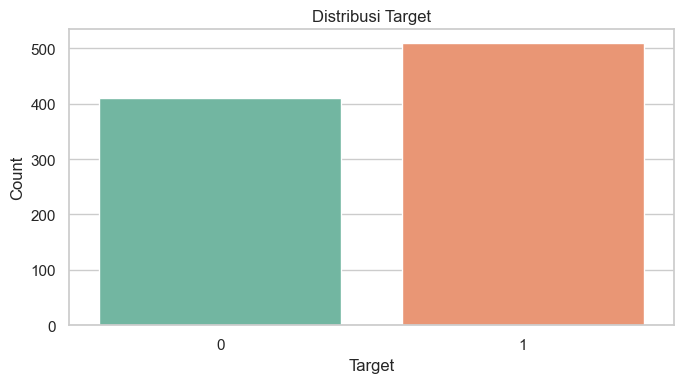

4. MISSING VALUES


,missing_count,missing_percentage
ca,611,66.413
thal,486,52.826
slope,309,33.587
fbs,90,9.783
oldpeak,62,6.739
trestbps,59,6.413
thalach,55,5.978
exang,55,5.978
chol,30,3.261
restecg,2,0.217


5. DUPLICATE RECORDS
Duplikat penuh (tanpa source_file): 2
Duplikat fitur dengan target berbeda: 4 baris
Duplikat identik antar semua kolom: 2


In [9]:
# 1-5. Ukuran data, tipe fitur, target, missing values, dan duplikasi
print("1. JUMLAH OBSERVASI DAN FITUR")
print(f"Observasi: {len(df):,}")
print(f"Fitur asli: {len(FEATURE_NAMES) - 1:,} | Target: 1 | Kolom metadata: source_file, target_binary")

print("\n2. TIPE SETIAP FITUR")
type_table = pd.DataFrame({
    "feature": df[FEATURE_NAMES].columns,
    "dtype": df[FEATURE_NAMES].dtypes.astype(str).values,
    "n_unique": df[FEATURE_NAMES].nunique(dropna=True).values,
})
display(type_table)

print("3. DISTRIBUSI TARGET")
target_distribution = pd.DataFrame({
    "count": df["target"].value_counts(dropna=False).sort_index(),
    "percentage": df["target"].value_counts(normalize=True, dropna=False).sort_index().mul(100),
})
display(target_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="target")
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("4. MISSING VALUES")
missing_table = pd.DataFrame({
    "missing_count": df[FEATURE_NAMES].isna().sum(),
    "missing_percentage": df[FEATURE_NAMES].isna().mean().mul(100),
}).sort_values("missing_count", ascending=False)
display(missing_table)

print("5. DUPLICATE RECORDS")
print(f"Duplikat penuh (tanpa source_file): {df[FEATURE_NAMES].duplicated().sum():,}")
print(f"Duplikat fitur dengan target berbeda: {df.duplicated(FEATURE_NAMES[:-1], keep=False).sum():,} baris")
print(f"Duplikat identik antar semua kolom: {df.duplicated().sum():,}")

6. DISTRIBUSI NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


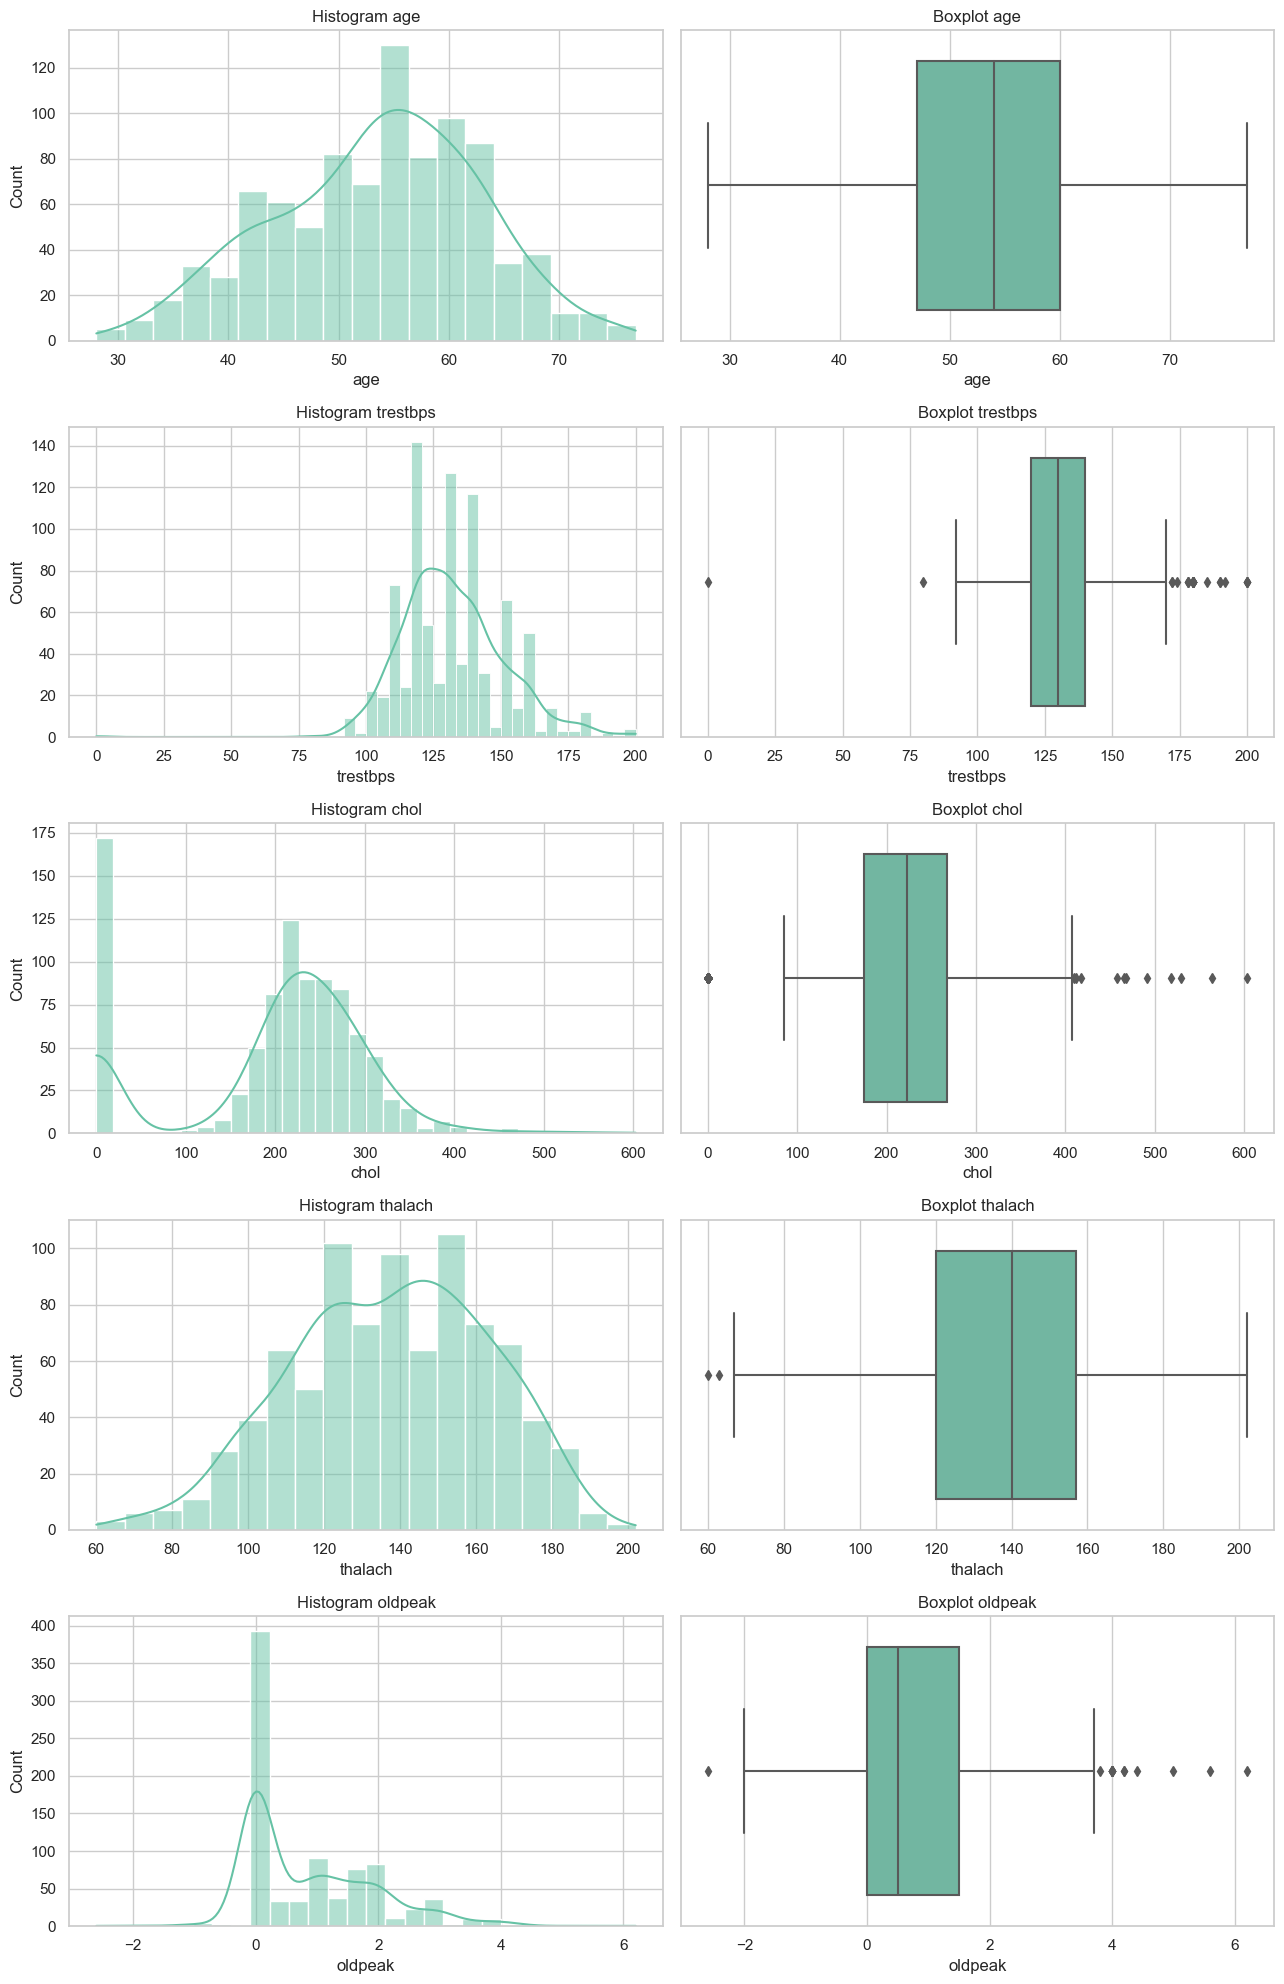

7. DISTRIBUSI CATEGORICAL FEATURES

sex


,count,percentage
sex,,
1.000,726,78.913
0.000,194,21.087


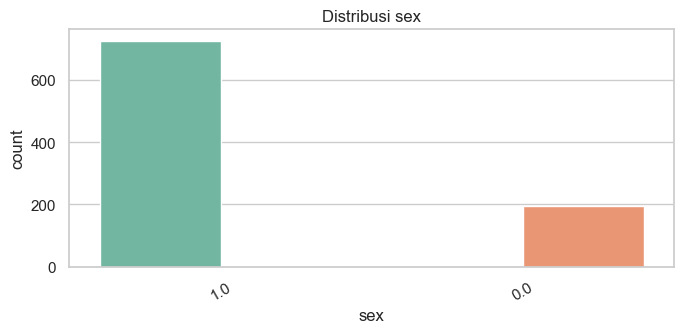


cp


,count,percentage
cp,,
4.000,496,53.913
3.000,204,22.174
2.000,174,18.913
1.000,46,5.000


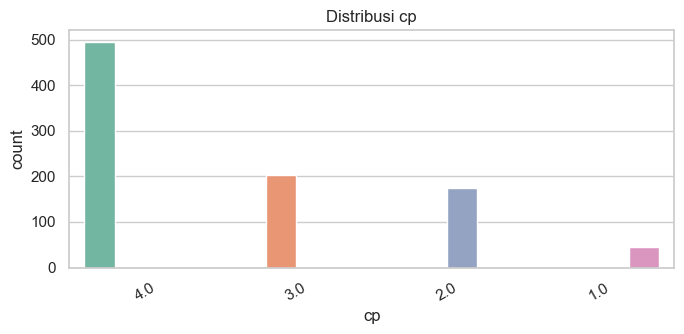


fbs


,count,percentage
fbs,,
0.000,692,75.217
1.000,138,15.000
NaN,90,9.783


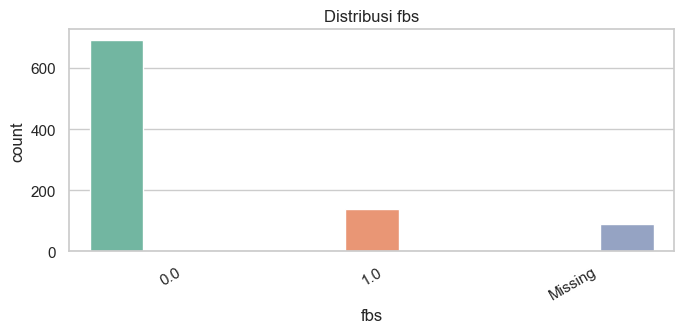


restecg


,count,percentage
restecg,,
0.000,551,59.891
2.000,188,20.435
1.000,179,19.457
NaN,2,0.217


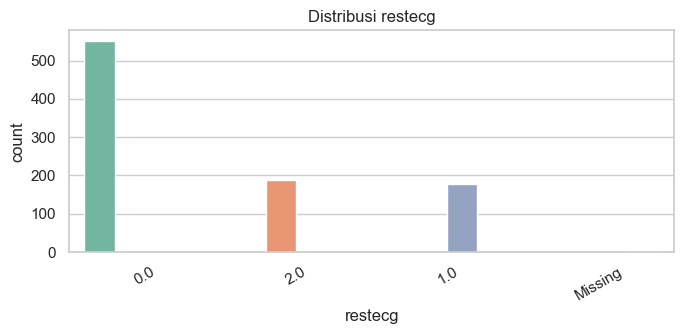


exang


,count,percentage
exang,,
0.000,528,57.391
1.000,337,36.630
NaN,55,5.978


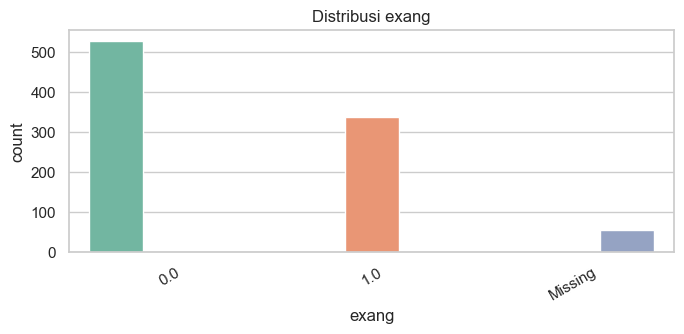


slope


,count,percentage
slope,,
2.000,345,37.500
NaN,309,33.587
1.000,203,22.065
3.000,63,6.848


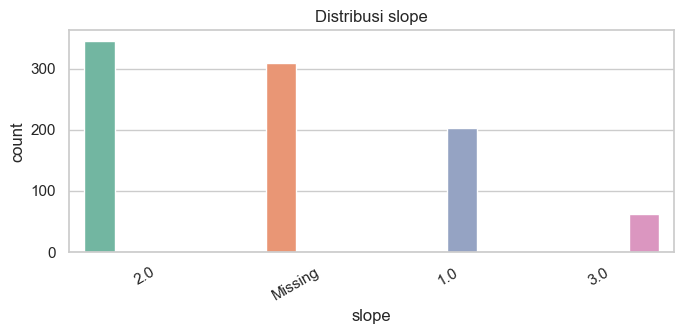


ca


,count,percentage
ca,,
NaN,611,66.413
0.000,181,19.674
1.000,67,7.283
2.000,41,4.457
3.000,20,2.174


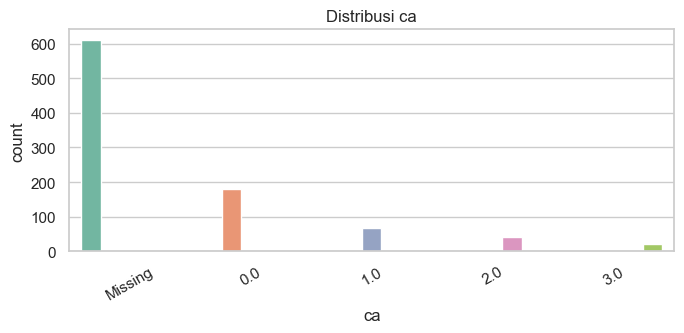


thal


,count,percentage
thal,,
NaN,486,52.826
3.000,196,21.304
7.000,192,20.870
6.000,46,5.000


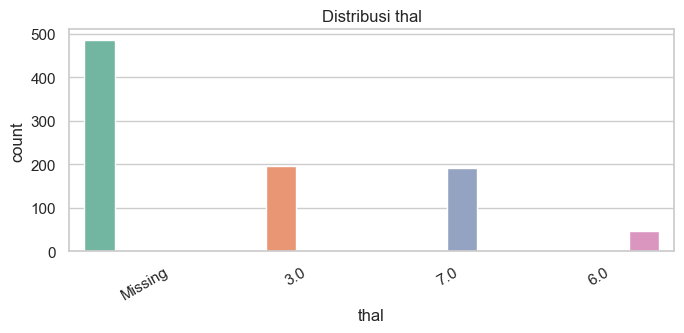

In [11]:
# 6-7. Distribusi fitur numerik dan kategorikal
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("6. DISTRIBUSI NUMERICAL FEATURES")
display(df[numeric_features].describe().T)
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(13, 4 * len(numeric_features)))
for row, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram {feature}")
    sns.boxplot(data=df, x=feature, ax=axes[row, 1])
    axes[row, 1].set_title(f"Boxplot {feature}")
plt.tight_layout()
plt.show()

print("7. DISTRIBUSI CATEGORICAL FEATURES")
for feature in categorical_features:
    distribution = df[feature].value_counts(dropna=False).rename_axis(feature).to_frame("count")
    distribution["percentage"] = distribution["count"].div(len(df)).mul(100)
    print(f"\n{feature}")
    display(distribution)

    # HANYA untuk plotting - df[feature] asli tidak disentuh
    plot_series = df[feature].astype(str).where(df[feature].notna(), "Missing")
    plot_order = plot_series.value_counts(dropna=False).index

    plt.figure(figsize=(7, 3.5))
    sns.countplot(
        x=plot_series,
        order=plot_order,
        hue=plot_series,
        hue_order=plot_order,
        palette="Set2",
    )
    plt.legend([], [], frameon=False)
    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

8. ANOMALOUS VALUES (ATURAN DOMAIN)


,feature,allowed_range,anomaly_count,anomaly_percentage
4,chol,"[50, 700]",172,18.696
3,trestbps,"[50, 250]",1,0.109
1,sex,"[0, 1]",0,0.000
0,age,"[0, 120]",0,0.000
2,cp,"[1, 4]",0,0.000
5,fbs,"[0, 1]",0,0.000
6,restecg,"[0, 2]",0,0.000
7,thalach,"[50, 250]",0,0.000
8,exang,"[0, 1]",0,0.000
9,oldpeak,"[-5, 10]",0,0.000


Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.
9. OUTLIER ANALYSIS (IQR)


,feature,q1,q3,lower_bound,upper_bound,outlier_count,outlier_percentage
2,chol,175.000,268.000,35.500,407.500,183,19.891
1,trestbps,120.000,140.000,90.000,170.000,28,3.043
4,oldpeak,0.000,1.500,-2.250,3.750,16,1.739
3,thalach,120.000,157.000,64.500,212.500,2,0.217
0,age,47.000,60.000,27.500,79.500,0,0.000


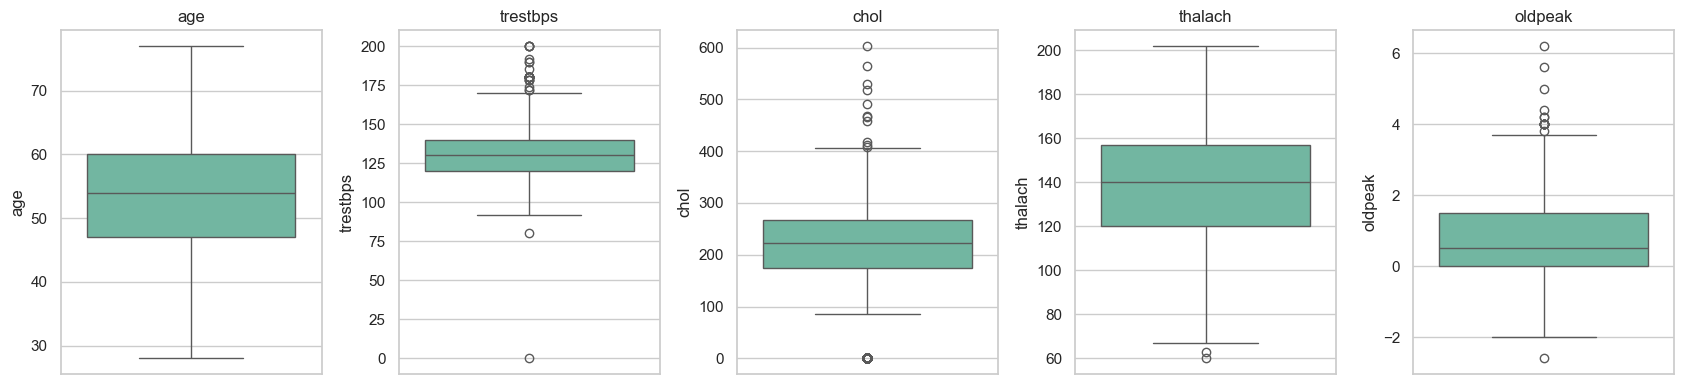

In [ ]:
# 8-9. Anomalous values dan outlier analysis
print("8. ANOMALOUS VALUES (ATURAN DOMAIN)")
domain_rules = {
    "age": (0, 120),
    "sex": (0, 1),
    "cp": (1, 4),
    "trestbps": (50, 250),
    "chol": (50, 700),
    "fbs": (0, 1),
    "restecg": (0, 2),
    "thalach": (50, 250),
    "exang": (0, 1),
    "oldpeak": (-5, 10),
    "slope": (1, 3),
    "ca": (0, 3),
    "thal": (3, 7),
    "target": (0, 1),
}
anomaly_rows = []
for feature, (lower, upper) in domain_rules.items():
    values = pd.to_numeric(df[feature], errors="coerce")
    mask = values.notna() & ~values.between(lower, upper)
    anomaly_rows.append({
        "feature": feature,
        "allowed_range": f"[{lower}, {upper}]",
        "anomaly_count": int(mask.sum()),
        "anomaly_percentage": mask.mean() * 100,
    })
anomaly_table = pd.DataFrame(anomaly_rows).sort_values("anomaly_count", ascending=False)
display(anomaly_table)
print("Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.")

print("9. OUTLIER ANALYSIS (IQR)")
outlier_rows = []
for feature in numeric_features:
    values = df[feature].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = df[feature].notna() & ~df[feature].between(lower, upper)
    outlier_rows.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": mask.mean() * 100,
    })
outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(17, 4))
for axis, feature in zip(axes, numeric_features):
    sns.boxplot(data=df, y=feature, ax=axis)
    axis.set_title(feature)
plt.tight_layout()
plt.show()

10. HUBUNGAN FEATURE DENGAN TARGET
Rata-rata fitur numerik berdasarkan target biner:


target                0       1
age      count  411.000 509.000
         mean    50.547  55.904
         median  51.000  57.000
trestbps count  391.000 470.000
         mean   129.913 133.979
         median 130.000 130.000
chol     count  392.000 498.000
         mean   227.906 176.480
         median 228.000 218.000
thalach  count  391.000 474.000
         mean   148.801 128.262
         median 151.000 128.000
oldpeak  count  390.000 468.000
         mean     0.418   1.263
         median   0.000   1.050

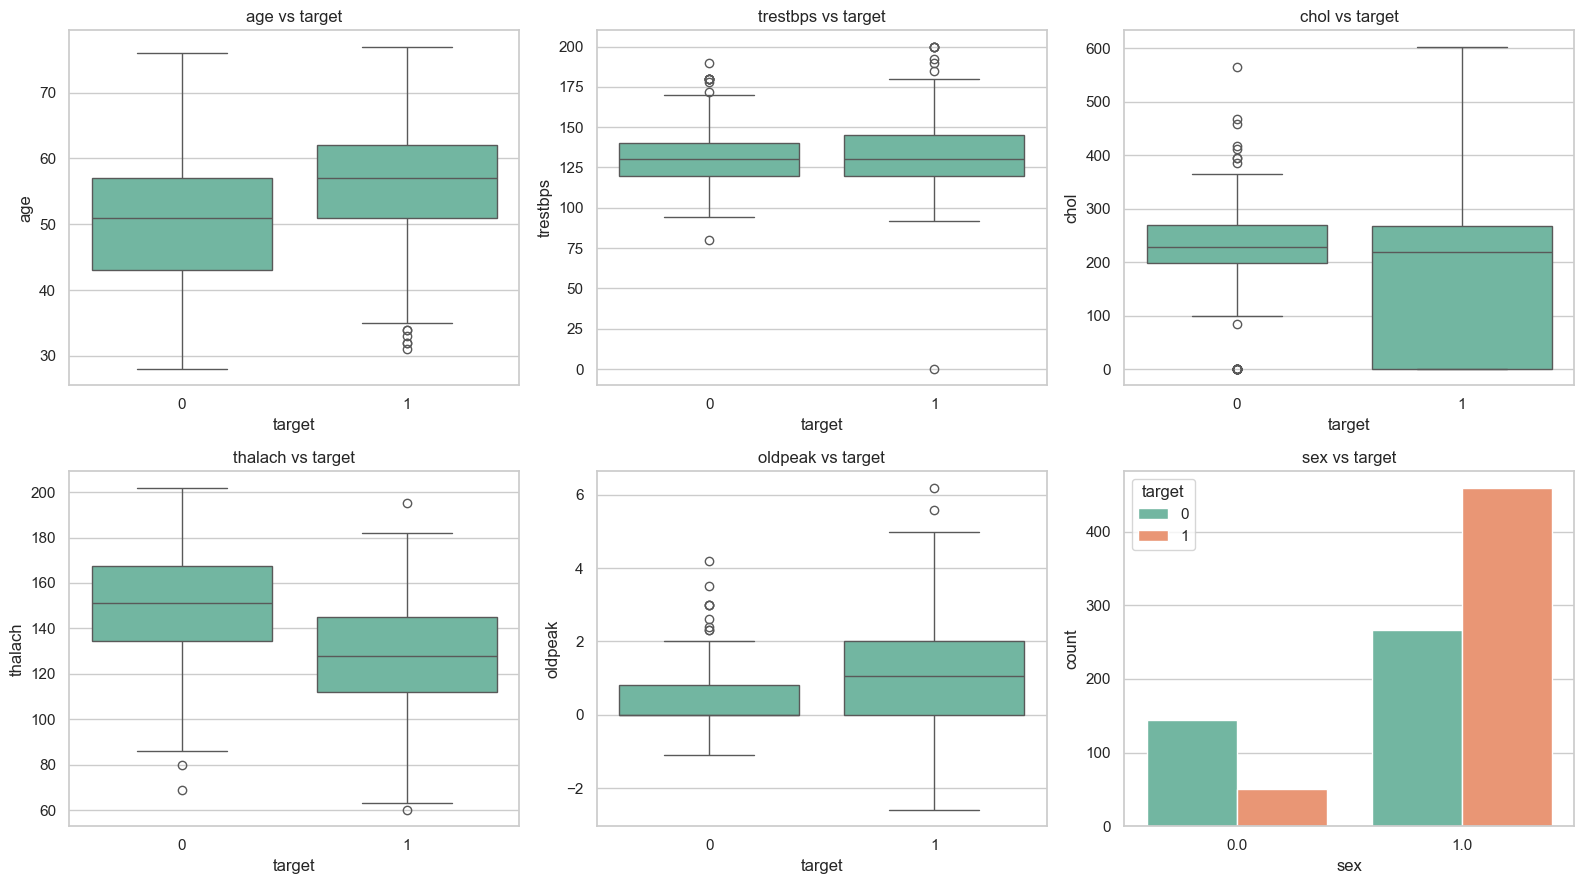


Positive rate berdasarkan sex


,count,positive_rate
sex,,
0.000,194,0.258
1.000,726,0.632



Positive rate berdasarkan cp


,count,positive_rate
cp,,
1.000,46,0.435
2.000,174,0.138
3.000,204,0.358
4.000,496,0.790



Positive rate berdasarkan fbs


...


Positive rate berdasarkan ca


,count,positive_rate
ca,,
0.000,181,0.265
1.000,67,0.687
2.000,41,0.805
3.000,20,0.850
NaN,611,0.597



Positive rate berdasarkan thal


,count,positive_rate
thal,,
3.000,196,0.296
6.000,46,0.761
7.000,192,0.802
NaN,486,0.539


11. CORRELATION ANALYSIS


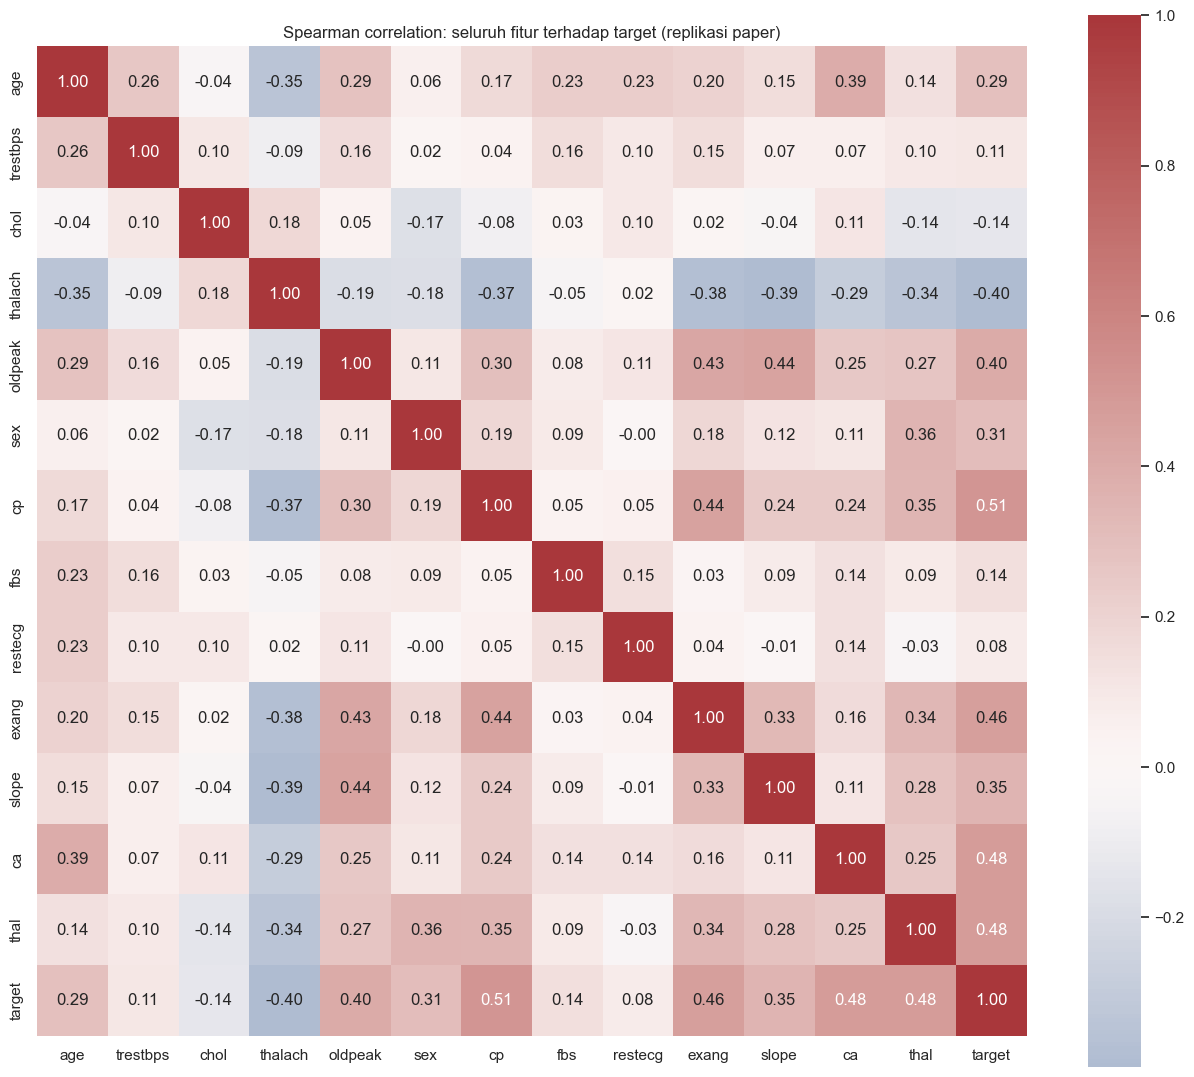

Korelasi Spearman terhadap target (seluruh fitur):


,spearman_corr
cp,0.511
ca,0.484
thal,0.484
exang,0.464
oldpeak,0.401
thalach,-0.399
slope,0.353
sex,0.307
age,0.291
fbs,0.143


In [ ]:
# 10-11. Hubungan fitur dengan target dan correlation analysis
print("10. HUBUNGAN FEATURE DENGAN TARGET")
print("Rata-rata fitur numerik berdasarkan target biner:")
display(df.groupby("target")[numeric_features].agg(["count", "mean", "median"]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, feature in zip(axes.flat, numeric_features):
    sns.boxplot(data=df, x="target", y=feature, ax=axis)
    axis.set_title(f"{feature} vs target")
for axis, feature in zip(axes.flat[len(numeric_features):], categorical_features[:1]):
    sns.countplot(data=df, x=feature, hue="target", ax=axis)
    axis.set_title(f"{feature} vs target")
for axis in axes.flat[(len(numeric_features) + 1):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

for feature in categorical_features:
    rates = df.groupby(feature, dropna=False)["target"].agg(["count", "mean"])
    rates = rates.rename(columns={"mean": "positive_rate"})
    print(f"\nPositive rate berdasarkan {feature}")
    display(rates)

print("11. CORRELATION ANALYSIS")

# Replikasi paper: seluruh fitur (numerik + kategorikal) dihitung dengan Spearman,
# tanpa membedakan skala data — mengikuti pendekatan paper aslinya apa adanya.
correlation_columns = numeric_features + categorical_features + ["target"]
correlation_matrix = df[correlation_columns].corr(method="spearman")

plt.figure(figsize=(13, 11))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlation: seluruh fitur terhadap target (replikasi paper)")
plt.tight_layout()
plt.show()

print("Korelasi Spearman terhadap target (seluruh fitur):")
display(correlation_matrix["target"].drop("target").sort_values(key=abs, ascending=False).to_frame("spearman_corr"))

In [ ]:
# 12. Potential data leakage
print("12. POTENTIAL DATA LEAKAGE")

leakage_checks = pd.DataFrame({
    "column": ["target", "source_file"],
    "reason": [
        "Label turunan dari target; tidak boleh menjadi predictor.",
        "Metadata sumber dataset; berpotensi membuat model belajar perbedaan subset/populasi.",
    ],
    "action": [
        "Drop sebelum split/train; hanya dipakai sebagai y.",
        "Drop dari X atau evaluasi secara eksplisit sebagai analisis subgroup.",
    ],
})
display(leakage_checks)

# Fitur model yang aman hanya berasal dari pengukuran pasien.
model_features = [feature for feature in FEATURE_NAMES if feature != "target"]
X_eda = df[model_features].copy()
y_eda = df["target"].copy()
print(f"Predictor awal yang dapat dipertimbangkan: {len(model_features)} fitur")
print("Wajib dilakukan setelah EDA: split train/test terlebih dahulu, lalu fit imputer/encoder hanya pada train.")

feature_columns = [feature for feature in FEATURE_NAMES if feature != "target"]
conflicting_groups = (
    df.dropna(subset=feature_columns)
      .groupby(feature_columns, dropna=False)["target"]
      .nunique()
)
print(f"Grup fitur identik dengan target berbeda: {(conflicting_groups > 1).sum():,}")
print("Interpretasi: target tidak dipakai sebagai fitur; source_file diperlakukan sebagai metadata, dan preprocessing di-fit setelah pembagian data.")

12. POTENTIAL DATA LEAKAGE


,column,reason,action
0,target,Label turunan dari target; tidak boleh menjadi...,Drop sebelum split/train; hanya dipakai sebaga...
1,source_file,Metadata sumber dataset; berpotensi membuat mo...,Drop dari X atau evaluasi secara eksplisit seb...


Predictor awal yang dapat dipertimbangkan: 13 fitur
Wajib dilakukan setelah EDA: split train/test terlebih dahulu, lalu fit imputer/encoder hanya pada train.
Grup fitur identik dengan target berbeda: 0
Interpretasi: target tidak dipakai sebagai fitur; source_file diperlakukan sebagai metadata, dan preprocessing di-fit setelah pembagian data.


## 3. Methodology Audit and Replication Design

### 3.1 Reported Experimental Pipeline

Rekonstruksi pipeline berdasarkan paper:

Data
→ preprocessing
→ feature selection/engineering
→ train-test split
→ model training
→ evaluation.

Berdasarkan informasi yang tersedia, paper melaporkan bahwa dataset UCI digunakan untuk prediksi penyakit jantung, lalu dilakukan preprocessing, split data, pelatihan model, dan evaluasi akurasi. Namun, paper tidak menjelaskan secara konsisten: sumber dataset yang tepat, filtering yang dilakukan, prosedur imputation dan scaling yang digunakan, random seed, serta detail hyperparameter untuk sebagian besar model. Karena informasi tersebut tidak lengkap, replikasi harus dibatasi pada interpretasi yang didukung oleh data dan metodologi yang masuk akal.

### 3.2 Methodological Issues, Ambiguities, and Decisions

1. Dataset
Paper melaporkan 503 observations dan 10 attributes, sedangkan dataset UCI yang tersedia dalam notebook tidak dapat direkonstruksi identik menjadi dataset paper. Karena tidak ada informasi lengkap tentang filtering, exclusion, atau langkah preprocessing yang menghasilkan 503 observasi, kita tidak menghapus data secara acak untuk mencapai jumlah tersebut. Ini dicatat sebagai reproducibility limitation.

2. Features
Paper menggunakan 10 predictor:
- sex
- age
- cp
- trestbps
- chol
- fbs
- restecg
- thalach
- exang
- oldpeak

Kita menggunakan 10 fitur ini untuk eksperimen replikasi utama dan tidak menggunakan slope, ca, dan thal.

3. Target
Target ditetapkan sebagai binary: num = 0 -> normal (0), num > 0 -> diseased (1). Jika target_binary sudah dibuat maka kita gunakan yang sudah ada dan tidak membuat duplikat.

4. Train-test split
Paper tidak konsisten: Proposed Methodology menyebut sekitar 70% training / 30% testing, sedangkan Proposed Model Overview menyebut 75% training / 25% testing. Untuk corrected replication utama, kita menggunakan 70:30 karena disebut pada bagian Proposed Methodology. Split dilakukan dengan stratification dan random_state=42 sebagai reproducibility assumption karena paper tidak melaporkan seed.

5. Missing values
Paper mengatakan missing values ditangani menggunakan mean. Namun corrected replication harus mencegah data leakage: split dilakukan sebelum fitting imputation, imputer hanya fit pada X_train, lalu transform X_train dan X_test. Untuk numerical continuous features kita gunakan mean imputation. Untuk categorical/binary features, jika mean imputation tidak metodologis, kita gunakan most_frequent dan dokumentasikan sebagai methodological correction.

6. Scaling
Paper menyebut data distandardisasi tetapi tidak menjelaskan detailnya. Kita gunakan StandardScaler hanya untuk model yang sensitif terhadap skala seperti SVM, KNN, RBF, dan LVQ. Scaler fit hanya pada training data. Tree-based models tidak perlu scaling. Kita menggunakan Pipeline/ColumnTransformer untuk mencegah leakage.

In [12]:
# replication setup: paper feature set and target normalization
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.base import clone

# Use the binary target already created in EDA; do not create another duplicate target variable.
# If target_binary exists, keep it as the source of truth.
paper_features = [
    "sex", "age", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak"
]

numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang"]

# Reproducibility limitation: the notebook dataset is the available UCI Heart Disease repository data,
# not a reconstructed 503-observation dataset from the paper.
print("Paper-reported dataset size (503 obs, 10 attributes): not reconstructible identically from the available UCI files in this notebook.")
print(f"Available UCI dataset size in notebook: {df.shape[0]} rows x {len(df.columns)} columns")
print("Status: dataset mismatch is documented as a reproducibility limitation; no random row deletion is performed.")

# Keep binary target as 0/1 because this is already created in the existing EDA workflow.
if "target_binary" in df.columns:
    df["target"] = df["target_binary"].astype(int)
else:
    df["target"] = (df["target"] > 0).astype(int)

X = df[paper_features].copy()
y = df["target"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
    shuffle=True,
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Positive class rate in full data: {y.mean():.3f}")
print(f"Positive class rate in train data: {y_train.mean():.3f}")
print(f"Positive class rate in test data: {y_test.mean():.3f}")

Paper-reported dataset size (503 obs, 10 attributes): not reconstructible identically from the available UCI files in this notebook.
Available UCI dataset size in notebook: 920 rows x 15 columns
Status: dataset mismatch is documented as a reproducibility limitation; no random row deletion is performed.
Train size: 644
Test size: 276
Positive class rate in full data: 0.553
Positive class rate in train data: 0.553
Positive class rate in test data: 0.554


### 3.3 Final Corrected Replication Pipeline

Implementasikan:

Available UCI Data
→ Select 10 paper features + binary target
→ Stratified 70:30 train-test split
→ Fit preprocessing ONLY on training data
→ Train models
→ Evaluate once on untouched test data.

In [13]:
# Preprocessing pipeline with leakage prevention

# Numeric features: mean imputation.
# For tree-based models, no scaling is applied.
# For SVM/KNN/RBF/LVQ, StandardScaler is used only after train/test split and fit on train only.
# Categorical/binary features: mode imputation is a methodological correction when mean is not meaningful.

numeric_transformer_no_scaling = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
])

numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_transformer_no_scaling, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor_scale_sensitive = ColumnTransformer([
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# A compact check to show the transformed feature count after preprocessing.
X_train_proc = preprocessor_tree.fit_transform(X_train)
X_test_proc = preprocessor_tree.transform(X_test)
print(f"Preprocessed train matrix shape (tree models): {X_train_proc.shape}")
print(f"Preprocessed test matrix shape (tree models): {X_test_proc.shape}")

X_train_proc_scaled = preprocessor_scale_sensitive.fit_transform(X_train)
X_test_proc_scaled = preprocessor_scale_sensitive.transform(X_test)
print(f"Preprocessed train matrix shape (scale-sensitive models): {X_train_proc_scaled.shape}")
print(f"Preprocessed test matrix shape (scale-sensitive models): {X_test_proc_scaled.shape}")

Preprocessed train matrix shape (tree models): (644, 18)
Preprocessed test matrix shape (tree models): (276, 18)
Preprocessed train matrix shape (scale-sensitive models): (644, 18)
Preprocessed test matrix shape (scale-sensitive models): (276, 18)


## 4. Model Replication

Paper membandingkan:
- Random Forest
- Decision Tree
- Support Vector Machine
- XGBoost
- K-Nearest Neighbour
- Naive Bayes
- Radial Basis Function
- Learning Vector Quantization

Kita tidak melakukan extensive hyperparameter tuning karena paper tidak memberikan hyperparameter lengkap. Parameter default/reasonable akan dipakai dan setiap parameter yang tidak tersedia dalam paper dicatat sebagai replication assumption.

Catatan penting:
- RBF diperlakukan sebagai approximation, karena pada paper ini tidak dijelaskan secara rinci apakah yang dimaksud adalah SVM dengan kernel rbf atau model RBF terpisah.
- LVQ tidak tersedia secara umum di scikit-learn, sehingga kita hanya akan menggunakannya jika package yang sesuai tersedia; jika tidak, hasil akan diberi label sebagai approximation/unsupported.

In [16]:
import numpy as np

# Model definitions: default/reasonable configuration without aggressive tuning.
# Tree-based models do NOT use scaling, while SVM/KNN/RBF/LVQ do.

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False
    xgb = None

# Optional LVQ implementation if available.
# Installed package is sklearn_lvq and the actual class is GlvqModel.
LVQ_AVAILABLE = False
LVQ_CLASSIFIER = None
try:
    from sklearn_lvq import GlvqModel
    LVQ_AVAILABLE = True
    LVQ_CLASSIFIER = GlvqModel(random_state=42)
except Exception:
    LVQ_CLASSIFIER = None

model_specs = {
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "preprocessor": preprocessor_tree,
        "status": "available",
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "preprocessor": preprocessor_tree,
        "status": "available",
    },
    "SVM": {
        "model": SVC(kernel="rbf", random_state=42),
        "preprocessor": preprocessor_scale_sensitive,
        "status": "available",
    },
    "XGBoost": {
        "model": None,
        "preprocessor": preprocessor_tree,
        "status": "unavailable",
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "preprocessor": preprocessor_scale_sensitive,
        "status": "available",
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "preprocessor": preprocessor_tree,
        "status": "available",
    },
    "RBF (approximation)": {
        "model": SVC(kernel="rbf", random_state=42),
        "preprocessor": preprocessor_scale_sensitive,
        "status": "approximation",
    },
    "LVQ (approximation/conditional)": {
        "model": LVQ_CLASSIFIER,
        "preprocessor": preprocessor_scale_sensitive,
        "status": "unavailable" if not LVQ_AVAILABLE else "available",
    },
}

if XGB_AVAILABLE:
    model_specs["XGBoost"]["model"] = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
    )
    model_specs["XGBoost"]["status"] = "available"
else:
    print("XGBoost tidak tersedia di environment saat ini; model ini akan di-skip.")

if LVQ_AVAILABLE:
    print("LVQ implementation tersedia; akan dipakai untuk replikasi terikat pada package yang ada.")
else:
    print("LVQ tidak tersedia di environment saat ini; model akan diberi label sebagai unimplemented approximation/unsupported.")

print("Daftar model yang akan diuji:")
for name in model_specs:
    if model_specs[name]["model"] is not None:
        print(f"- {name}: {type(model_specs[name]['model']).__name__}")
    else:
        print(f"- {name}: skipped (status: {model_specs[name].get('status', 'unknown')})")

LVQ implementation tersedia; akan dipakai untuk replikasi terikat pada package yang ada.
Daftar model yang akan diuji:
- Random Forest: RandomForestClassifier
- Decision Tree: DecisionTreeClassifier
- SVM: SVC
- XGBoost: XGBClassifier
- KNN: KNeighborsClassifier
- Naive Bayes: GaussianNB
- RBF (approximation): SVC
- LVQ (approximation/conditional): GlvqModel


In [17]:
# Training and evaluation loop
from sklearn.exceptions import NotFittedError

results = []

def model_evaluation(name, model, preprocessor, X_train, y_train, X_test, y_test):
    if model is None:
        print(f"Model {name} dilewati karena tidak tersedia dalam environment.")
        return None

    model_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    model_pipe.fit(X_train, y_train)
    y_pred = model_pipe.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    result = {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "Confusion Matrix": cm,
    }
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall/Sensitivity: {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1-score: {f1:.4f}")
    print("Confusion matrix:\n", cm)
    return result

for model_name, spec in model_specs.items():
    model_obj = spec["model"]
    preprocessor_obj = spec["preprocessor"]
    if model_obj is None:
        results.append({
            "Model": model_name,
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "Specificity": np.nan,
            "F1": np.nan,
            "Confusion Matrix": np.array([[np.nan, np.nan], [np.nan, np.nan]]),
            "Status": spec.get("status", "unavailable")
        })
        print(f"\n=== {model_name} ===")
        print("Status: not available in this environment / approximation-only")
        continue

    result = model_evaluation(model_name, model_obj, preprocessor_obj, X_train, y_train, X_test, y_test)
    if result is not None:
        result["Status"] = spec.get("status", "trained")
        results.append(result)

results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "Specificity": r["Specificity"],
        "F1": r["F1"],
        "Confusion Matrix": r["Confusion Matrix"].tolist() if isinstance(r["Confusion Matrix"], np.ndarray) else r["Confusion Matrix"],
        "Status": r.get("Status", "trained"),
    }
    for r in results
])

print("\nDataFrame hasil seluruh model:")
display(results_df)



=== Random Forest ===
Accuracy: 0.8080
Precision: 0.8289
Recall/Sensitivity: 0.8235
Specificity: 0.7886
F1-score: 0.8262
Confusion matrix:
 [[ 97  26]
 [ 27 126]]

=== Decision Tree ===
Accuracy: 0.7101
Precision: 0.7355
Recall/Sensitivity: 0.7451
Specificity: 0.6667
F1-score: 0.7403
Confusion matrix:
 [[ 82  41]
 [ 39 114]]

=== SVM ===
Accuracy: 0.8152
Precision: 0.8269
Recall/Sensitivity: 0.8431
Specificity: 0.7805
F1-score: 0.8350
Confusion matrix:
 [[ 96  27]
 [ 24 129]]

=== XGBoost ===
Accuracy: 0.8080
Precision: 0.8247
Recall/Sensitivity: 0.8301
Specificity: 0.7805
F1-score: 0.8274
Confusion matrix:
 [[ 96  27]
 [ 26 127]]

=== KNN ===
Accuracy: 0.8261
Precision: 0.8387
Recall/Sensitivity: 0.8497
Specificity: 0.7967
F1-score: 0.8442
Confusion matrix:
 [[ 98  25]
 [ 23 130]]

=== Naive Bayes ===
Accuracy: 0.8333
Precision: 0.8690
Recall/Sensitivity: 0.8235
Specificity: 0.8455
F1-score: 0.8456
Confusion matrix:
 [[104  19]
 [ 27 126]]

=== RBF (approximation) ===
Accuracy: 0.815

,Model,Accuracy,Precision,Recall,Specificity,F1,Confusion Matrix,Status
0,Random Forest,0.808,0.829,0.824,0.789,0.826,"[[97, 26], [27, 126]]",available
1,Decision Tree,0.710,0.735,0.745,0.667,0.740,"[[82, 41], [39, 114]]",available
2,SVM,0.815,0.827,0.843,0.780,0.835,"[[96, 27], [24, 129]]",available
3,XGBoost,0.808,0.825,0.830,0.780,0.827,"[[96, 27], [26, 127]]",available
4,KNN,0.826,0.839,0.850,0.797,0.844,"[[98, 25], [23, 130]]",available
5,Naive Bayes,0.833,0.869,0.824,0.846,0.846,"[[104, 19], [27, 126]]",available
6,RBF (approximation),0.815,0.827,0.843,0.780,0.835,"[[96, 27], [24, 129]]",approximation
7,LVQ (approximation/conditional),0.764,0.789,0.784,0.740,0.787,"[[91, 32], [33, 120]]",available


## 5. Evaluation

Untuk setiap model kita hitung:
- Accuracy
- Precision
- Sensitivity/Recall
- Specificity
- F1-score
- Confusion Matrix

Positive class = diseased (1).

Specificity didefinisikan sebagai TN / (TN + FP).

In [18]:
# Paper-vs-replication comparison using Table 12 values from paper.

paper_table_12 = {
    "Random Forest": 88.78,
    "Decision Tree": 89.78,
    "SVM": 86.78,
    "XGBoost": 87.78,
    "RBF": 90.78,
    "KNN": 79.78,
    "LVQ": 98.78,
    "Naive Bayes": 94.78,
}

paper_model_order = [
    "Random Forest",
    "Decision Tree",
    "SVM",
    "XGBoost",
    "KNN",
    "Naive Bayes",
    "RBF (approximation)",
    "LVQ (approximation/conditional)",
]

paper_vs_replication = []
for model_name in paper_model_order:
    result = next((r for r in results if r["Model"] == model_name), None)
    rep_acc = np.nan if result is None or pd.isna(result.get("Accuracy")) else result["Accuracy"] * 100

    if model_name == "RBF (approximation)":
        paper_acc = paper_table_12["RBF"]
    elif model_name == "LVQ (approximation/conditional)":
        paper_acc = paper_table_12["LVQ"]
    elif model_name == "SVM":
        paper_acc = paper_table_12["SVM"]
    elif model_name == "KNN":
        paper_acc = paper_table_12["KNN"]
    elif model_name == "Random Forest":
        paper_acc = paper_table_12["Random Forest"]
    elif model_name == "Decision Tree":
        paper_acc = paper_table_12["Decision Tree"]
    elif model_name == "XGBoost":
        paper_acc = paper_table_12["XGBoost"]
    elif model_name == "Naive Bayes":
        paper_acc = paper_table_12["Naive Bayes"]
    else:
        paper_acc = np.nan

    diff = np.nan if pd.isna(rep_acc) or pd.isna(paper_acc) else rep_acc - paper_acc
    paper_vs_replication.append({
        "Model": model_name,
        "Paper Accuracy (%)": paper_acc,
        "Replication Accuracy (%)": rep_acc,
        "Difference (% point)": diff,
        "Status": "trained" if result is not None and not pd.isna(result.get("Accuracy")) else "not available / approximation-only",
    })

comparison_df = pd.DataFrame(paper_vs_replication)
print("Tabel perbandingan paper vs replication:")
display(comparison_df)


Tabel perbandingan paper vs replication:


,Model,Paper Accuracy (%),Replication Accuracy (%),Difference (% point),Status
0,Random Forest,88.780,80.797,-7.983,trained
1,Decision Tree,89.780,71.014,-18.766,trained
2,SVM,86.780,81.522,-5.258,trained
3,XGBoost,87.780,80.797,-6.983,trained
4,KNN,79.780,82.609,2.829,trained
5,Naive Bayes,94.780,83.333,-11.447,trained
6,RBF (approximation),90.780,81.522,-9.258,trained
7,LVQ (approximation/conditional),98.780,76.449,-22.331,trained


## 6. Paper vs Replication

Bandingkan dengan hasil Table 12 paper:

Random Forest accuracy = 88.78%
Decision Tree = 89.78%
SVM = 86.78%
XGBoost = 87.78%
RBF = 90.78%
KNN = 79.78%
LVQ = 98.78%
Naive Bayes = 94.78%

Tabel berikut menampilkan selisih akurasi antara nilai paper dan replikasi.

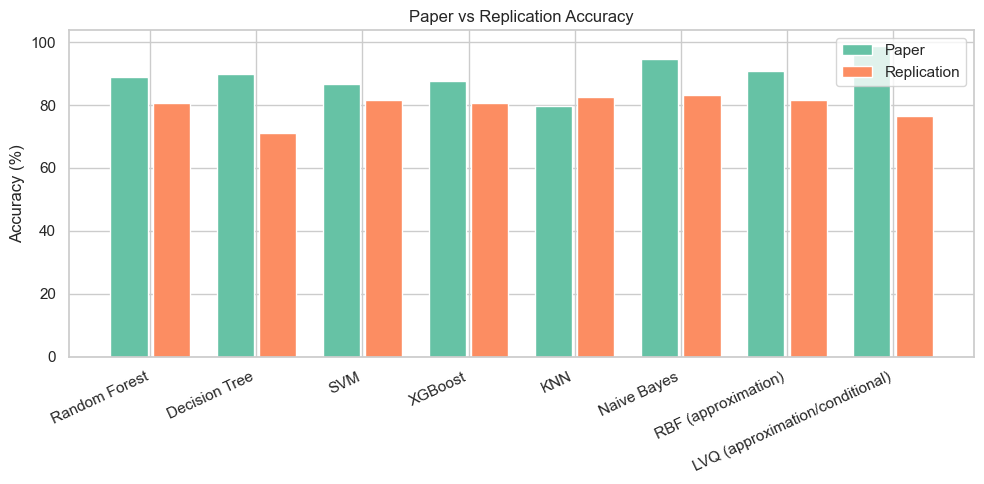

In [19]:
# Optional plotting for paper-vs-replication comparison
plt.figure(figsize=(10, 5))
bar_positions = np.arange(len(comparison_df))
plt.bar(bar_positions - 0.2, comparison_df["Paper Accuracy (%)"], width=0.35, label="Paper")
plt.bar(bar_positions + 0.2, comparison_df["Replication Accuracy (%)"], width=0.35, label="Replication")
plt.xticks(bar_positions, comparison_df["Model"], rotation=25, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Paper vs Replication Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Discussion

Beberapa kemungkinan penyebab hasil replikasi berbeda dari paper:

- dataset paper 503 observations tidak dapat direkonstruksi secara identik
- available UCI dataset berbeda dan tidak jelas filtering/selection yang digunakan paper
- paper tidak konsisten mengenai split 70:30 vs 75:25
- random seed tidak dilaporkan
- hyperparameter sebagian besar tidak dijelaskan secara lengkap
- corrected preprocessing dilakukan setelah splitting untuk mencegah data leakage
- beberapa model seperti RBF dan LVQ memerlukan pendekatan approximation karena tidak dijelaskan secara teknis di paper

Catatan penting: replikasi yang benar dalam konteks ilmiah tidak boleh mengubah preprocessing atau hyperparameter semata-mata untuk mengejar kecocokan angka paper. Tujuan utama adalah transparansi, reproduktifitas yang jujur, dan pemahaman terhadap keterbatasan metodologis yang tidak bisa dipastikan dari publikasi.

## Final Notes

Semua EDA dari notebook sebelumnya dipertahankan. Bagian baru di notebook ini fokus pada audit metodologi paper dan replika yang sesuai dengan prinsip kejujuran ilmiah: data leakage prevention, split yang jelas, penggunaan 10 fitur paper, target biner, dan evaluasi yang dilakukan hanya sekali pada test set yang tidak disentuh.